In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
plt.style.use("seaborn-v0_8-dark")

In [2]:
df = pd.read_csv('datasets/creditcardfraud/creditcard.csv')
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,-1.593105,2.711941,-0.689256,4.626942,-0.924459,1.107641,1.991691,0.510632,-0.682920,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,-0.150189,0.915802,1.214756,-0.675143,1.164931,-0.711757,-0.025693,-1.221179,-1.545556,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,0.411614,0.063119,-0.183699,-0.510602,1.329284,0.140716,0.313502,0.395652,-0.577252,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,-1.933849,-0.962886,-1.042082,0.449624,1.962563,-0.608577,0.509928,1.113981,2.897849,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [17]:
def compute_mad_iqr_limits(x: np.ndarray, mad_threshold: float = 4.0, iqr_k: float = 1.5):
    '''
    Retorna límites (low/high) para MAD e IQR.
    Maneja MAD=0 o IQR=0 devolviendo límites iguales (luego se decide con fallback).
    '''
    x = x[np.isfinite(x)]
    if x.size == 0:
        return None

    # MAD
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    low_mad = med - mad_threshold * mad
    high_mad = med + mad_threshold * mad

    # IQR
    q1 = np.percentile(x, 25)
    q3 = np.percentile(x, 75)
    iqr = q3 - q1
    low_iqr = q1 - iqr_k * iqr
    high_iqr = q3 + iqr_k * iqr

    return {
        'median': med,
        'mad': mad,
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'low_mad': low_mad,
        'high_mad': high_mad,
        'low_iqr': low_iqr,
        'high_iqr': high_iqr,
        'min': float(np.min(x)),
        'max': float(np.max(x)),
    }

def pick_best_bound(x: np.ndarray, cand_a: float, name_a: str, cand_b: float, name_b: str, side: str):
    '''
    side: 'lower' o 'upper'
    - lower: minimiza count(x < limit)
    - upper: minimiza count(x > limit)
    Tiebreak:
      - lower: el límite más cercano al MIN (|limit - min| menor)
      - upper: el límite más cercano al MAX (|limit - max| menor)
    '''
    x = x[np.isfinite(x)]
    if x.size == 0:
        return None

    xmin, xmax = float(np.min(x)), float(np.max(x))

    def score(limit: float):
        if side == 'lower':
            out = int(np.sum(x < limit))
            tie = abs(limit - xmin)  # más cercano al mínimo
        else:
            out = int(np.sum(x > limit))
            tie = abs(limit - xmax)  # más cercano al máximo
        return out, tie

    out_a, tie_a = score(cand_a)
    out_b, tie_b = score(cand_b)

    # Preferir menor outlier count
    if out_a < out_b:
        return cand_a, name_a, out_a
    if out_b < out_a:
        return cand_b, name_b, out_b

    # Empate: elegir más cercano al extremo (min o max)
    if tie_a < tie_b:
        return cand_a, name_a, out_a
    if tie_b < tie_a:
        return cand_b, name_b, out_b

    # Empate total: deja A
    return cand_a, name_a, out_a

def _bin_edges_from_data(x: np.ndarray, bins: int):
    '''
    Bins fijos (edges) para reproducir exactamente el mismo binning.
    '''
    xmin = float(np.min(x))
    xmax = float(np.max(x))
    if xmin == xmax:
        # caso degenerado: crear edges artificiales
        eps = 1e-9 if xmin == 0 else abs(xmin) * 1e-9
        xmin, xmax = xmin - eps, xmax + eps
    return np.linspace(xmin, xmax, bins + 1)

def plot_histogram_hybrid_two_panels(series: pd.Series,
                                     title: str,
                                     median: float,
                                     low_mad: float, high_mad: float,
                                     low_iqr: float, high_iqr: float,
                                     chosen_low: float, chosen_low_name: str,
                                     chosen_high: float, chosen_high_name: str,
                                     out_low_count: int, out_high_count: int,
                                     bins: int = 30):
    x_all = series.to_numpy(dtype=float)
    x_all = x_all[np.isfinite(x_all)]
    if x_all.size == 0:
        return

    xmin, xmax = float(np.min(x_all)), float(np.max(x_all))

    # Mismo binning para ambos plots
    edges = _bin_edges_from_data(x_all, bins=bins)
    bin_width = edges[1] - edges[0]

    # Datos acotados por límites elegidos
    x_clip = x_all[(x_all >= chosen_low) & (x_all <= chosen_high)]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

    # --- Panel 1: full distribution ---
    ax = axes[0]
    sns.histplot(
        x_all,
        bins=edges,
        kde=False,
        color='royalblue',
        edgecolor='royalblue',
        alpha=0.7,
        ax=ax
    )

    # Líneas MAD / IQR
    ax.axvline(median, linestyle='-', linewidth=2, color='black', label=f'Median')
    ax.axvline(low_mad,  linewidth=2, alpha=0.35, color='green', label=f'MAD')
    ax.axvline(high_mad, linewidth=2, alpha=0.35, color='green', label=f'_nolegend_')
    ax.axvline(low_iqr,  linestyle='-', linewidth=2, alpha=0.6, color='darkblue', label=f'IQR')
    ax.axvline(high_iqr, linestyle='-', linewidth=2, alpha=0.6, color='darkblue', label=f'_nolegend_')

    ax.set_title(f'{title}\nFull distribution', fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    # # Texto info
    # y_top = ax.get_ylim()[1]
    # ax.text(
    #     xmax, y_top * 0.95,
    #     f'min={xmin:.4g}\nmax={xmax:.4g}',
    #     ha='right', va='top', fontsize=9, fontweight='bold'
    # )

    ax.legend()

    # --- Panel 2: clipped to chosen limits, same bins/edges ---
    ax2 = axes[1]
    edges2 = np.linspace(chosen_low, chosen_high, bins + 1)
    sns.histplot(
        x_clip,
        bins=edges2,                  # mismo binning
        kde=False,
        color='royalblue',
        edgecolor='royalblue',
        alpha=0.7,
        ax=ax2
    )

    # Zoom de ejes al rango elegido (acotado visualmente)
    ax2.set_xlim(chosen_low, chosen_high)

    # Re-marcar límites elegidos (para contexto)
    ax2.axvline(chosen_low,  linewidth=5, alpha=0.9, color='red',
                label=f'Chosen LOW ({chosen_low_name})')
    ax2.axvline(chosen_high, linewidth=5, alpha=0.9, color='darkgreen',
                label=f'Chosen HIGH ({chosen_high_name})')

    ax2.set_title(f'{title}\nClipped to chosen limits', fontweight='bold')
    ax2.set_xlabel('Value')
    ax2.set_ylabel('Frequency')
    ax2.grid(axis='y', linestyle='--', alpha=0.4)

    # # Texto info: cuántos quedaron dentro
    # y_top2 = ax2.get_ylim()[1]
    # ax2.text(
    #     chosen_high, y_top2 * 0.95,
    #     f'kept={x_clip.size}/{x_all.size}',
    #     ha='right', va='top', fontsize=9, fontweight='bold'
    # )

    ax2.legend()

    plt.tight_layout()
    plt.show()


def detect_outliers_limits_all_numeric(df: pd.DataFrame,
                                       mad_threshold: float = 4.0,
                                       iqr_k: float = 1.5,
                                       bins: int = 30,
                                       max_plots: int | None = None):
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    rows = []
    plotted = 0

    for col in num_cols:
        s = df[col].dropna()
        x = s.to_numpy(dtype=float)
        x = x[np.isfinite(x)]

        if x.size < 5:
            rows.append({
                'column': col,
                'status': 'skipped (too few values)',
                'chosen_low': np.nan, 'chosen_low_method': None,
                'chosen_high': np.nan, 'chosen_high_method': None,
                'low_mad': np.nan, 'high_mad': np.nan,
                'low_iqr': np.nan, 'high_iqr': np.nan,
                'below_count': np.nan, 'above_count': np.nan
            })
            continue

        info = compute_mad_iqr_limits(x, mad_threshold=mad_threshold, iqr_k=iqr_k)
        if info is None:
            continue

        chosen_low, chosen_low_name, out_low = pick_best_bound(
            x, info['low_mad'], 'MAD', info['low_iqr'], 'IQR', side='lower'
        )
        chosen_high, chosen_high_name, out_high = pick_best_bound(
            x, info['high_mad'], 'MAD', info['high_iqr'], 'IQR', side='upper'
        )

        rows.append({
            'column': col,
            'status': 'ok',
            'chosen_low': chosen_low,
            'chosen_low_method': chosen_low_name,
            'chosen_high': chosen_high,
            'chosen_high_method': chosen_high_name,
            'low_mad': info['low_mad'],
            'high_mad': info['high_mad'],
            'low_iqr': info['low_iqr'],
            'high_iqr': info['high_iqr'],
            'below_count': out_low,
            'above_count': out_high,
            'median': info['median'],
            'mad': info['mad'],
            'iqr': info['iqr'],
            'min': info['min'],
            'max': info['max'],
        })

        if max_plots is None or plotted < max_plots:
            plot_histogram_hybrid_two_panels(
                series=s,
                title=f'{col} | Hybrid (LOW={chosen_low_name}, HIGH={chosen_high_name})',
                median=info['median'],
                low_mad=info['low_mad'], high_mad=info['high_mad'],
                low_iqr=info['low_iqr'], high_iqr=info['high_iqr'],
                chosen_low=chosen_low, chosen_low_name=chosen_low_name,
                chosen_high=chosen_high, chosen_high_name=chosen_high_name,
                out_low_count=out_low, out_high_count=out_high,
                bins=bins
            )
            plotted += 1

    return pd.DataFrame(rows).sort_values('column').reset_index(drop=True)

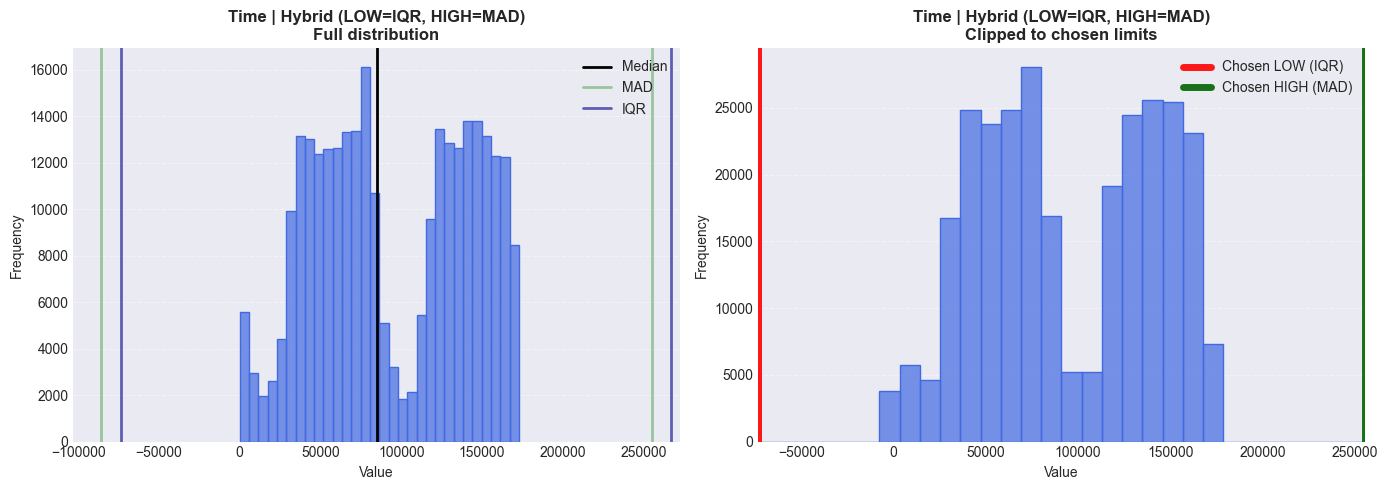

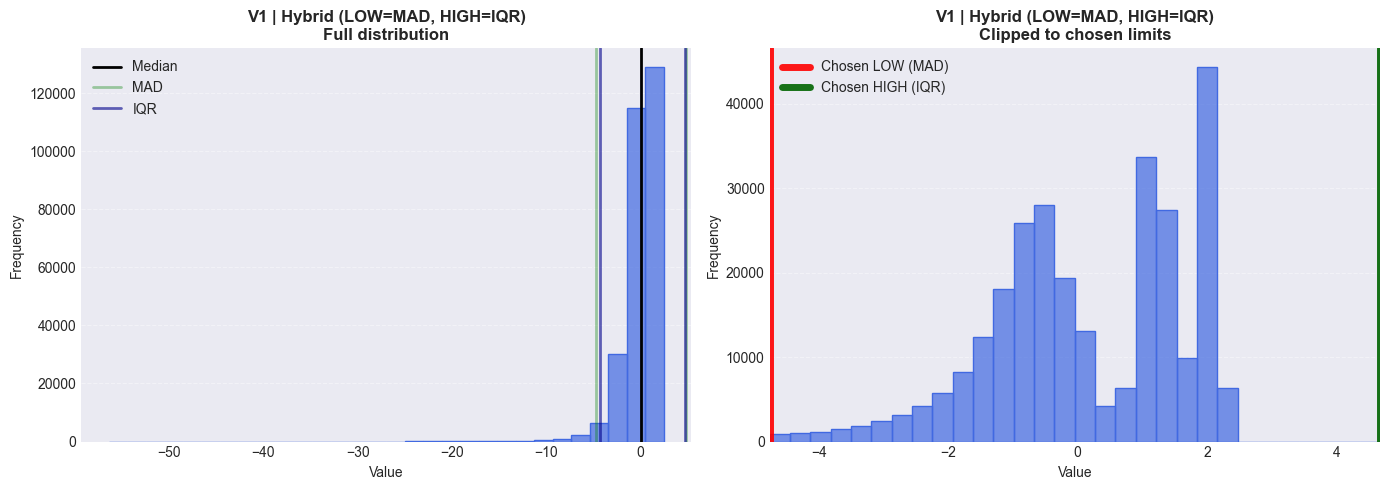

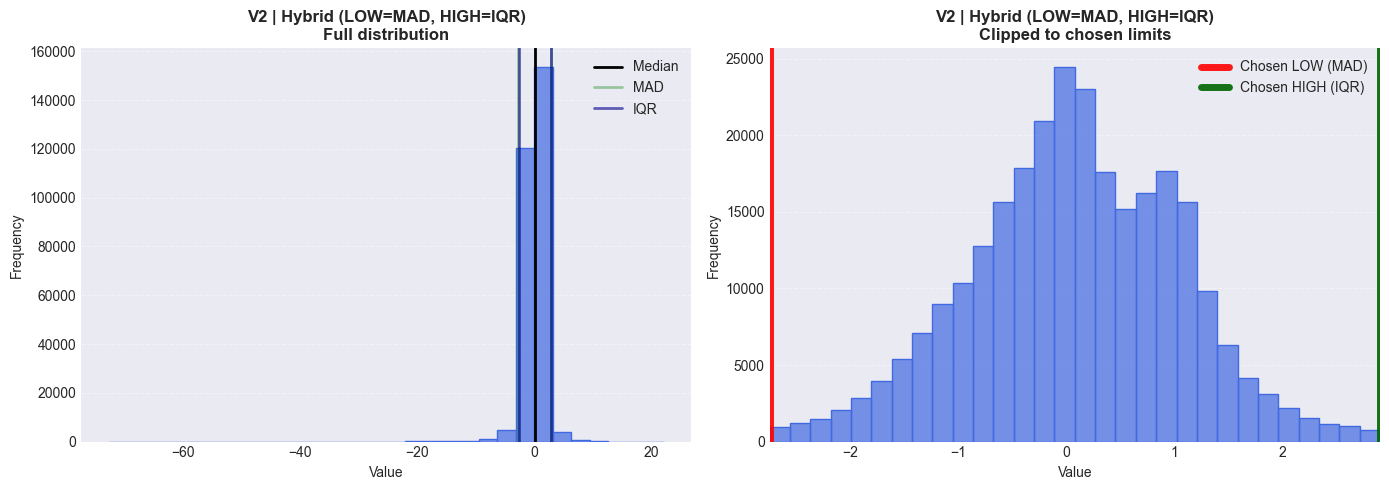

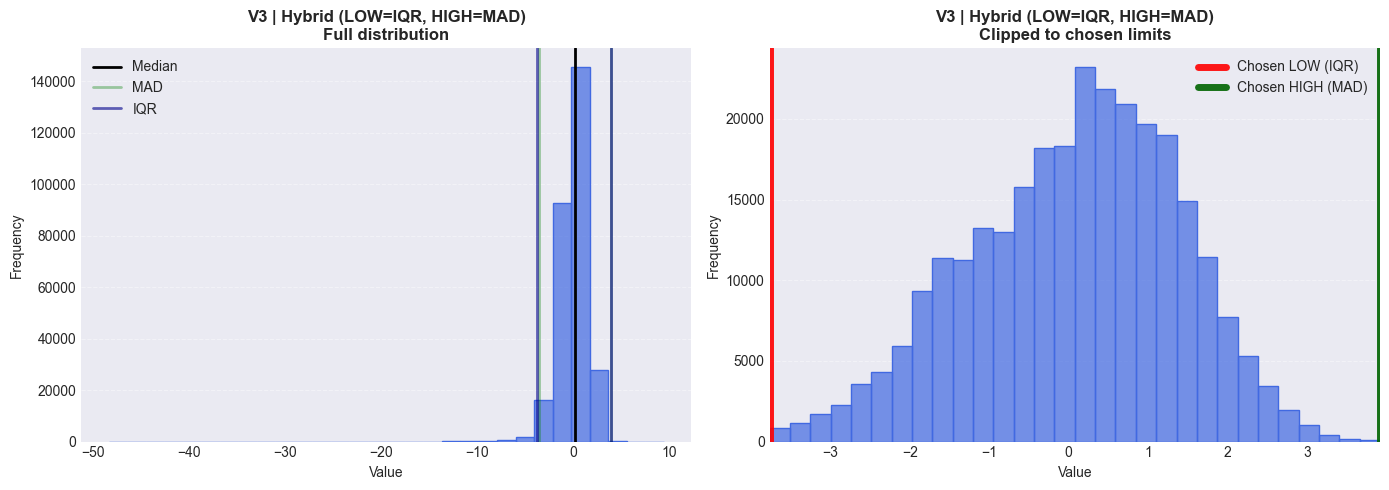

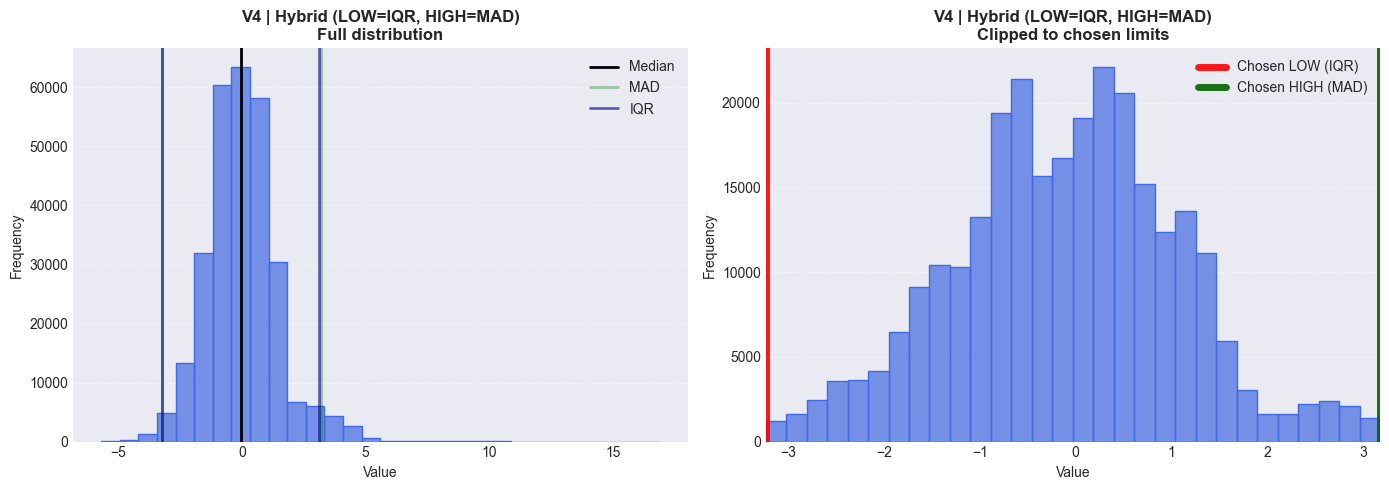

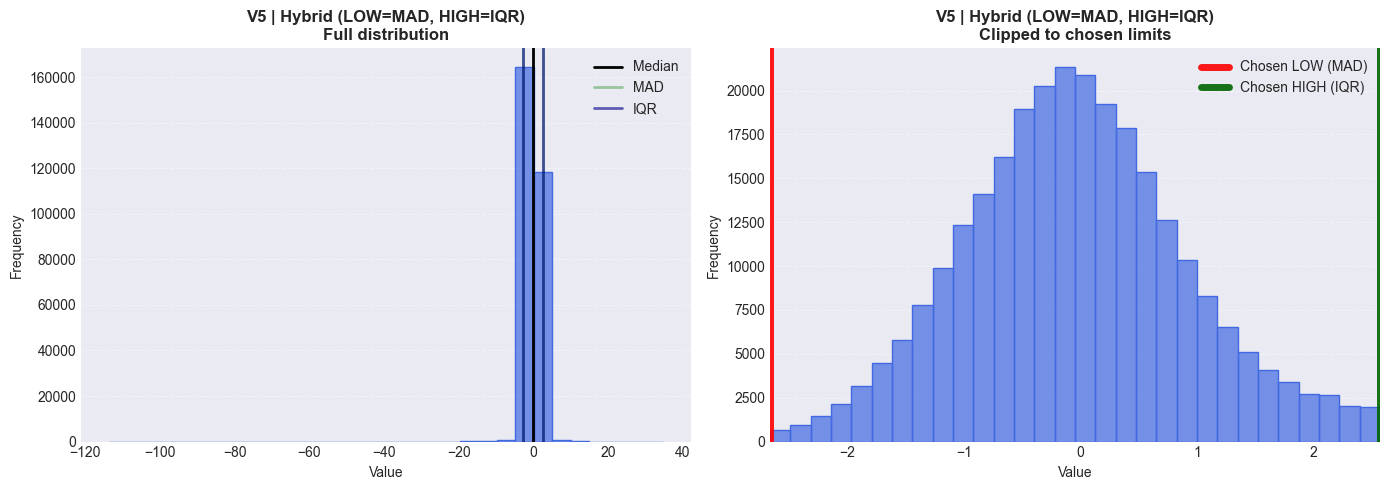

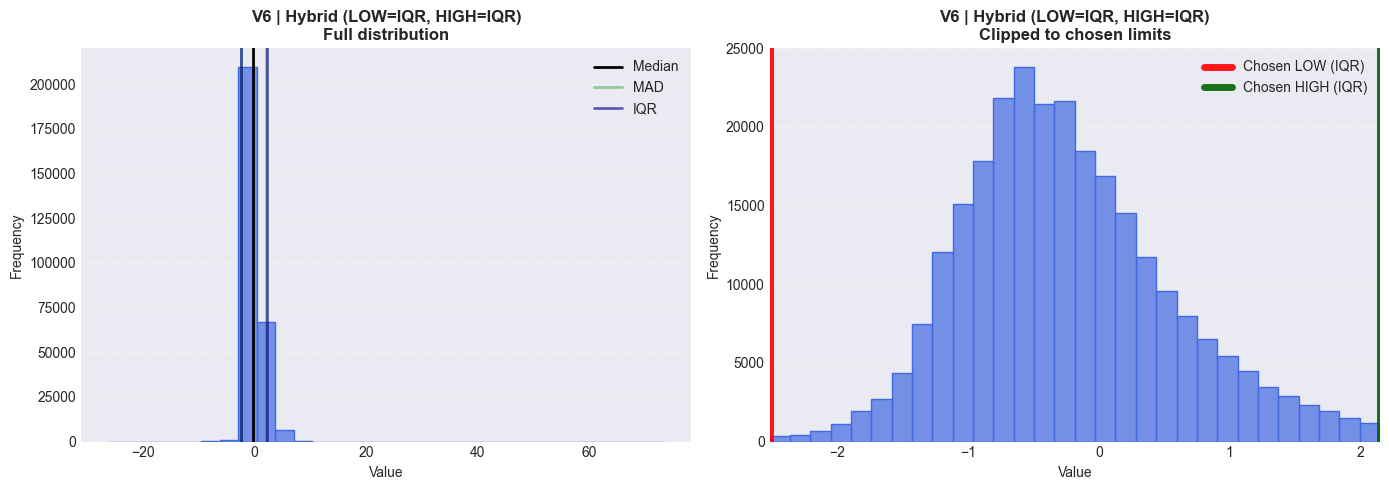

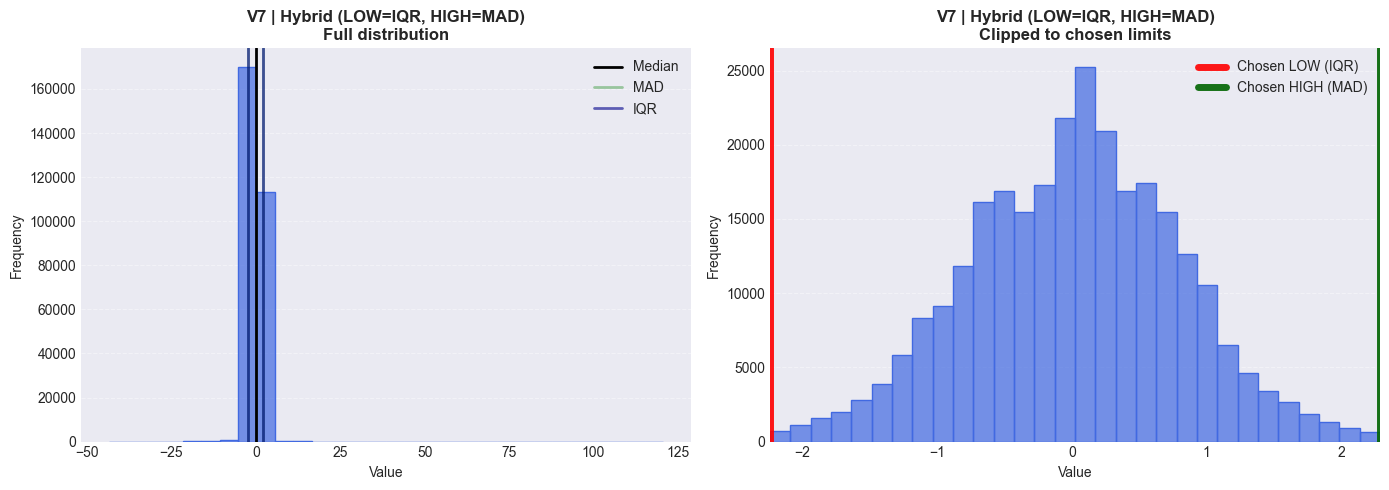

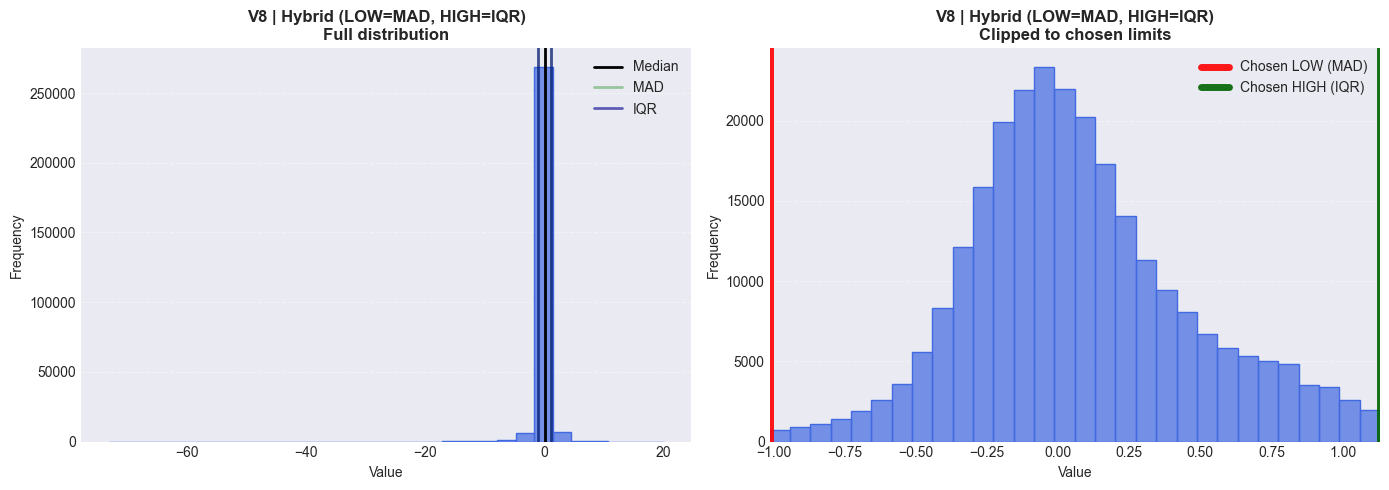

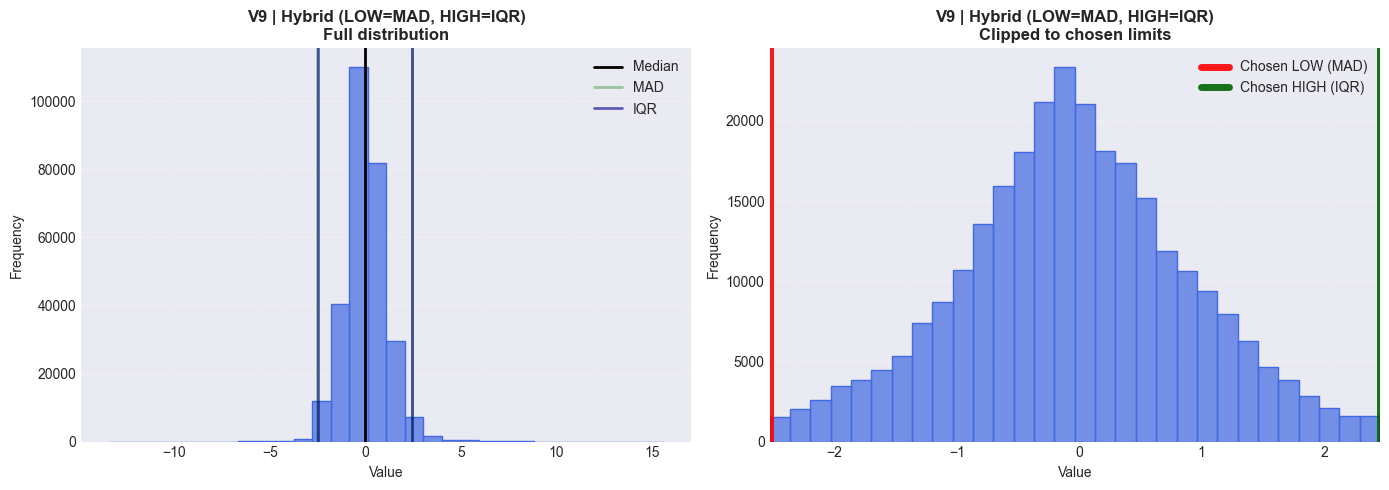

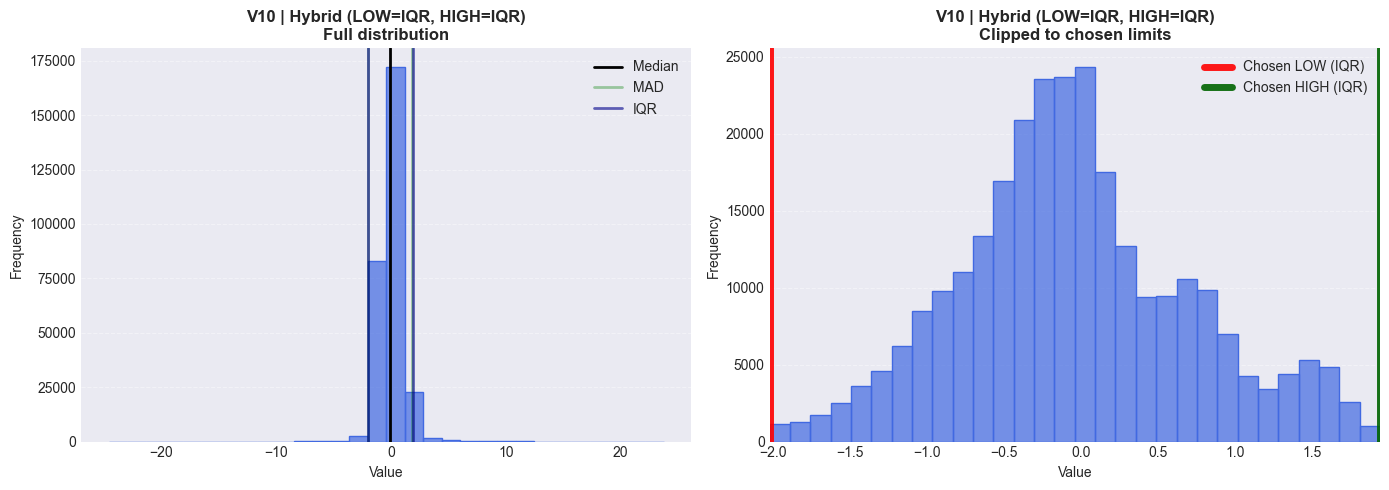

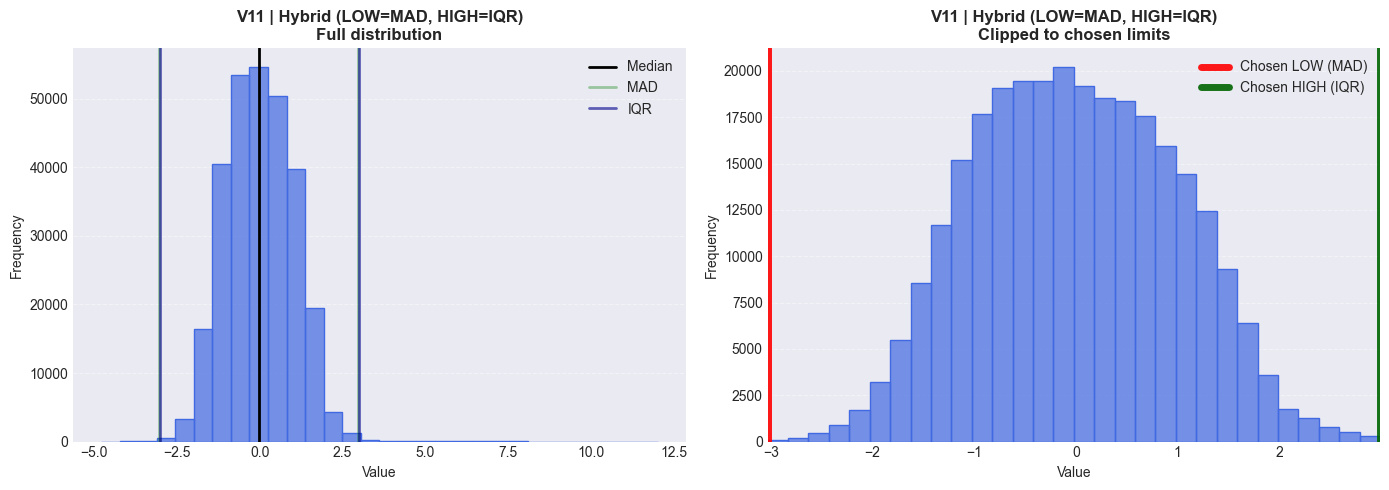

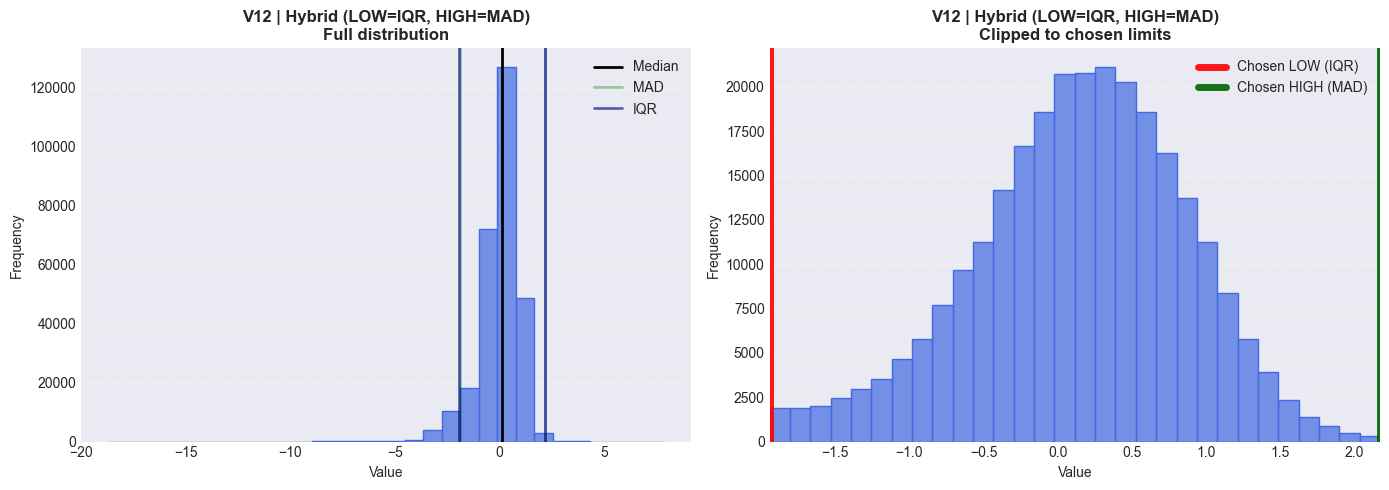

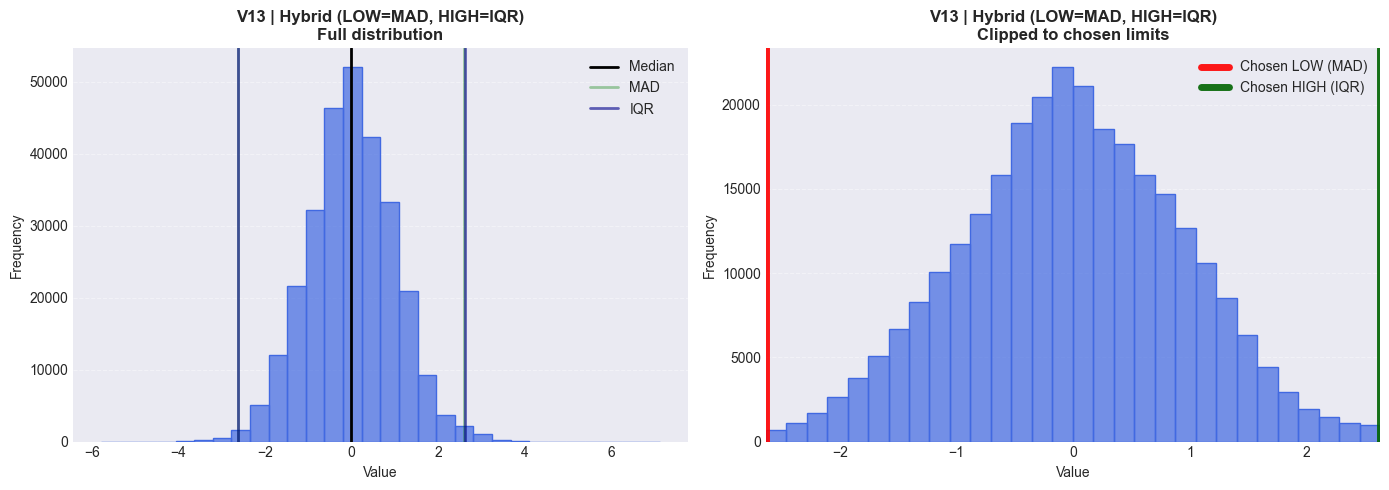

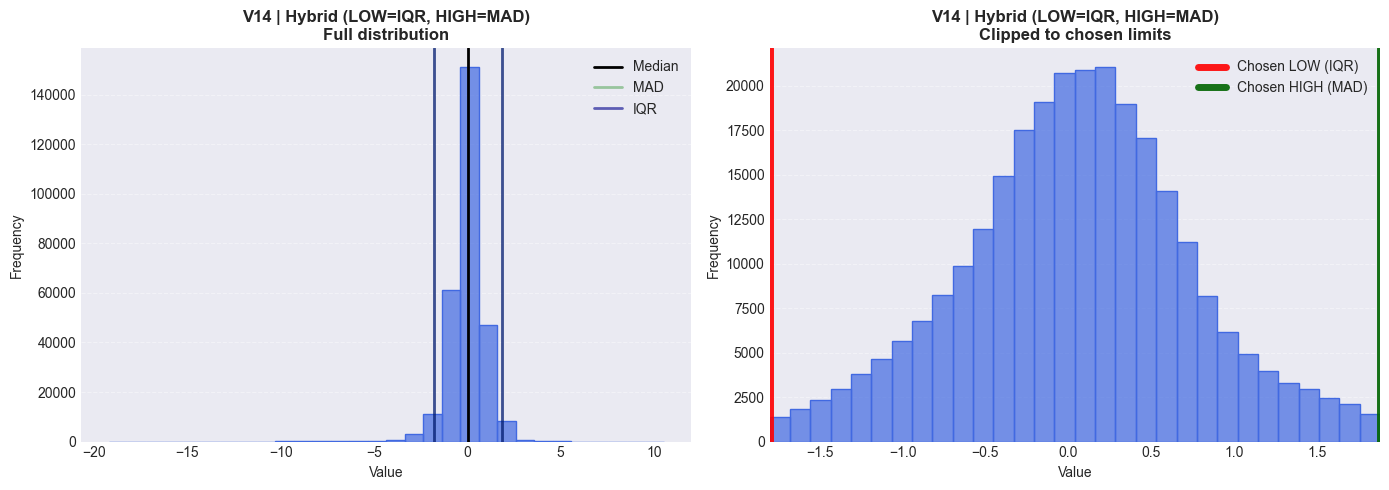

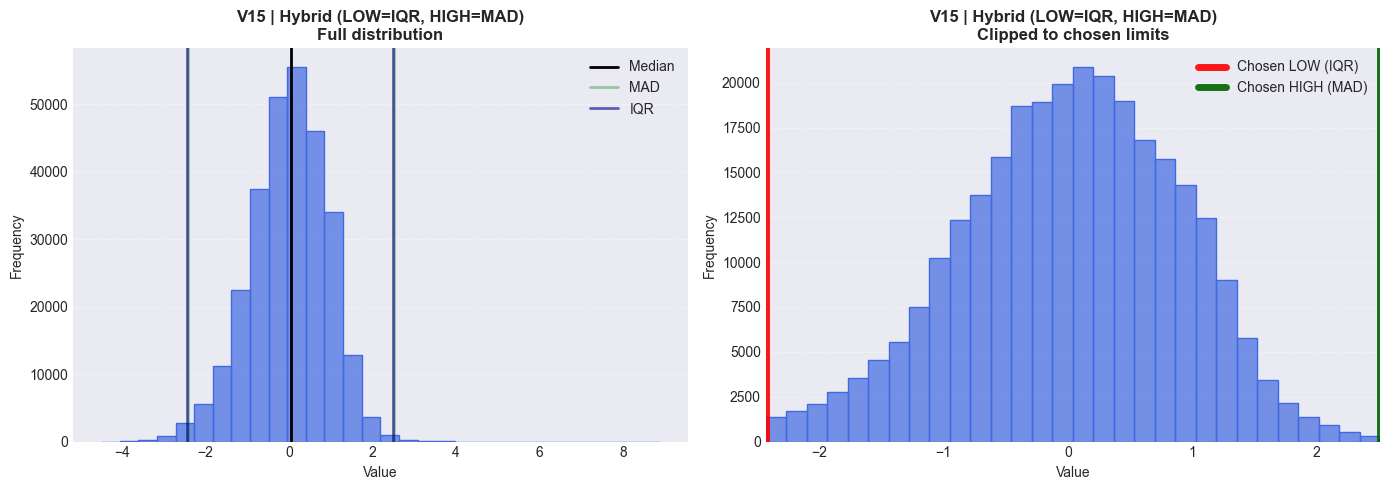

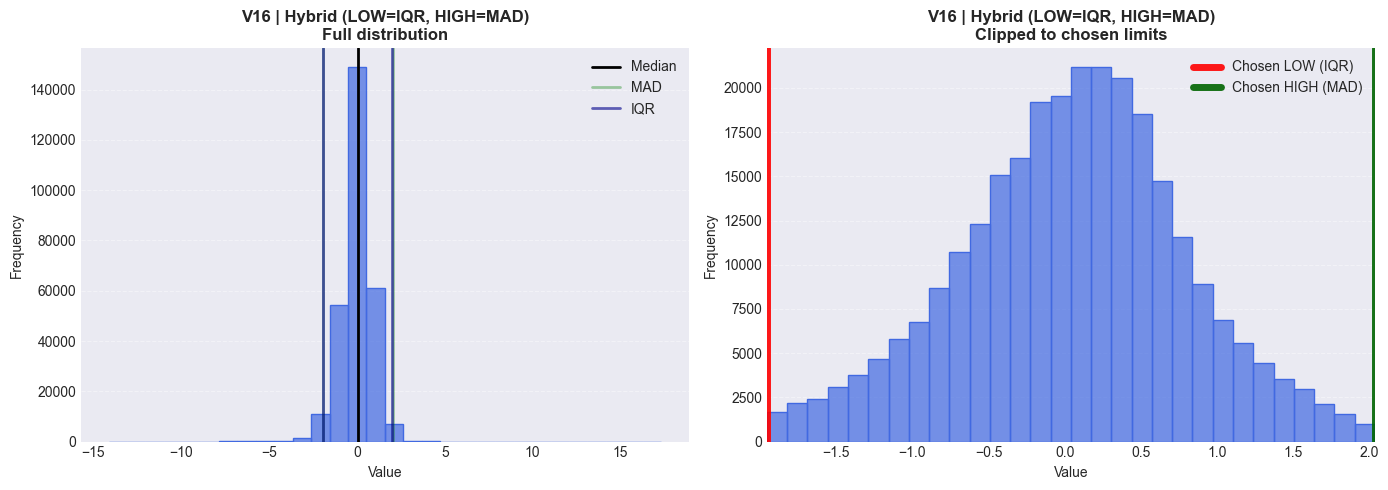

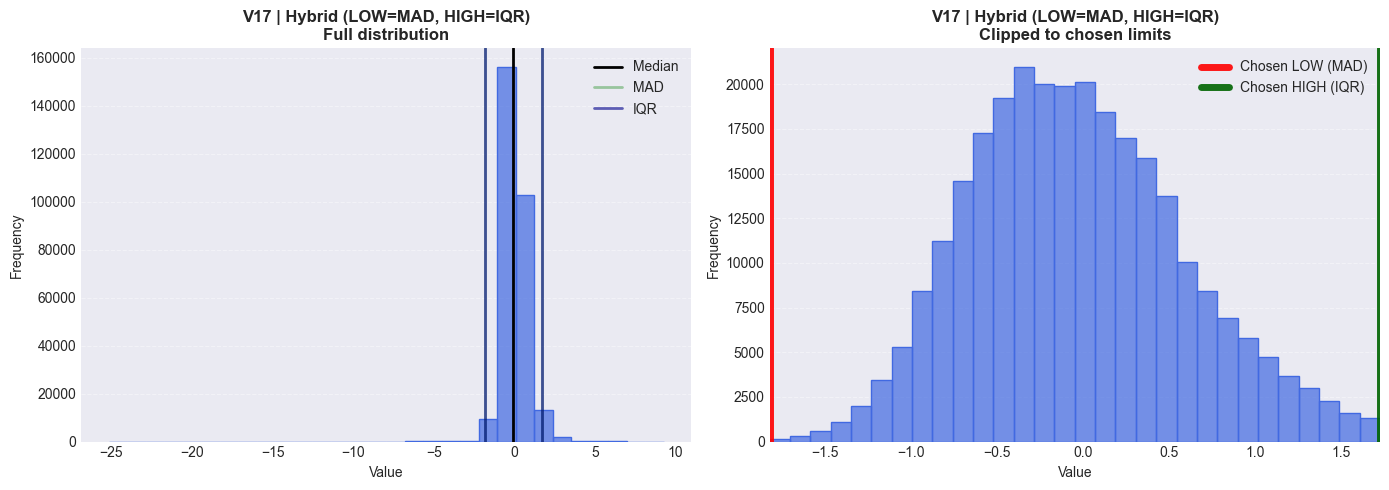

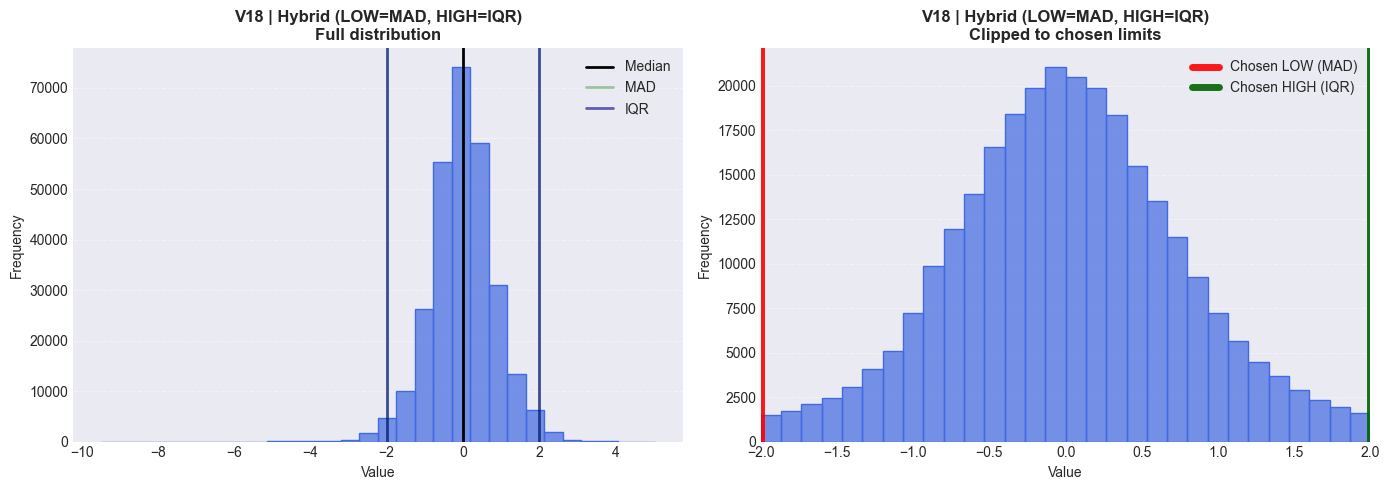

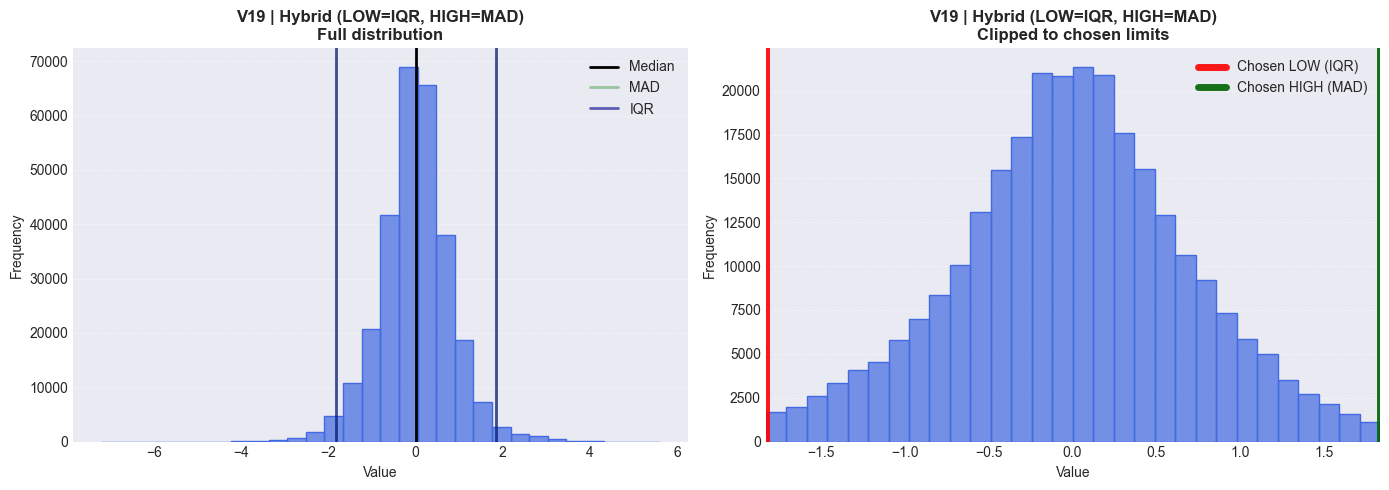

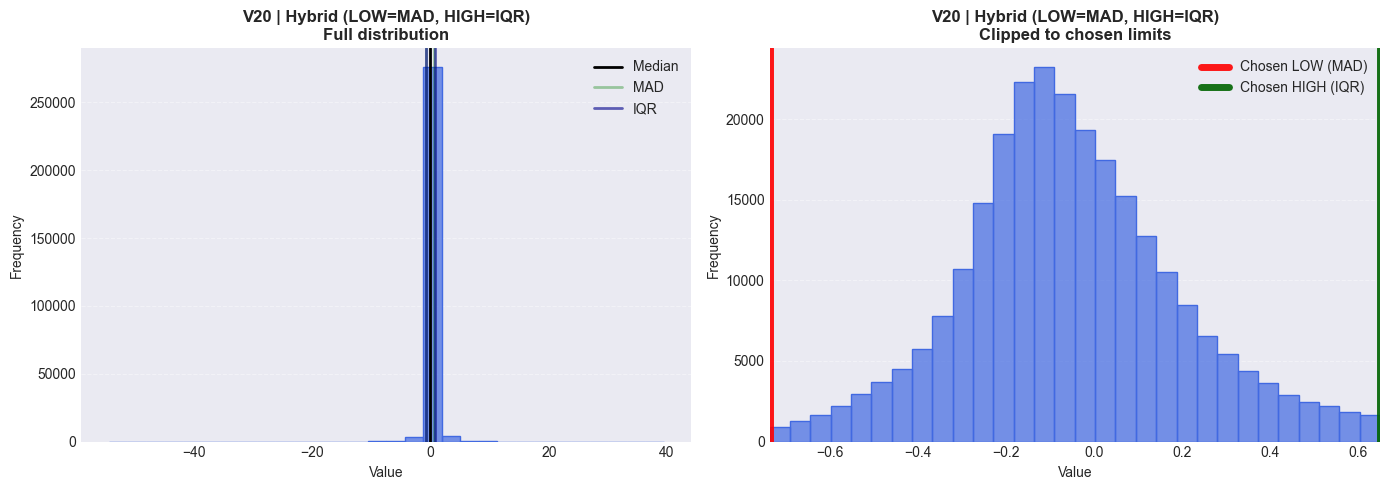

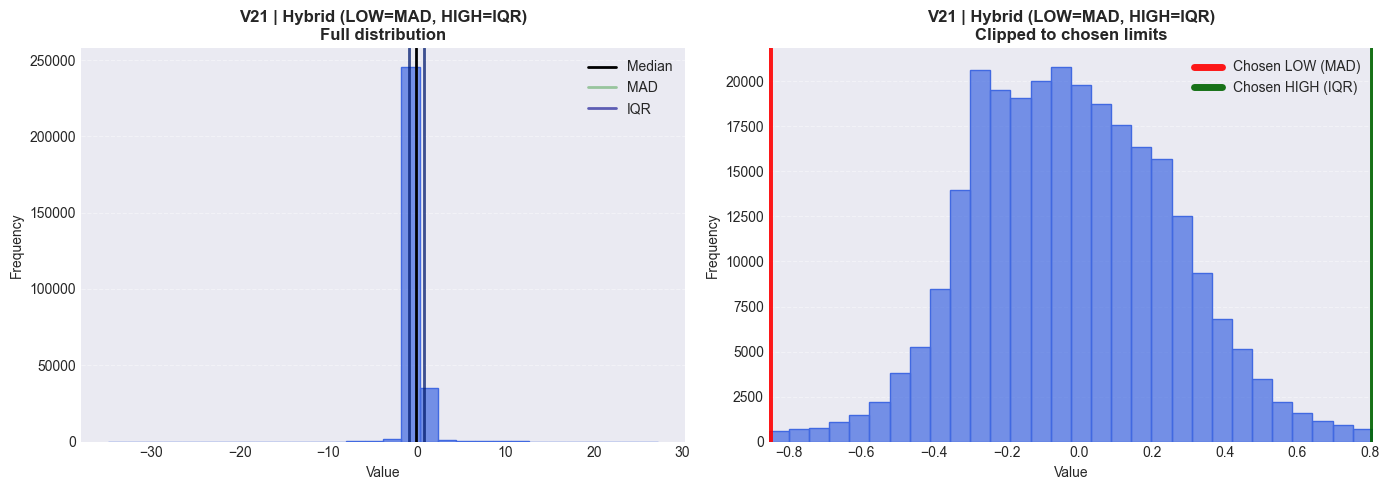

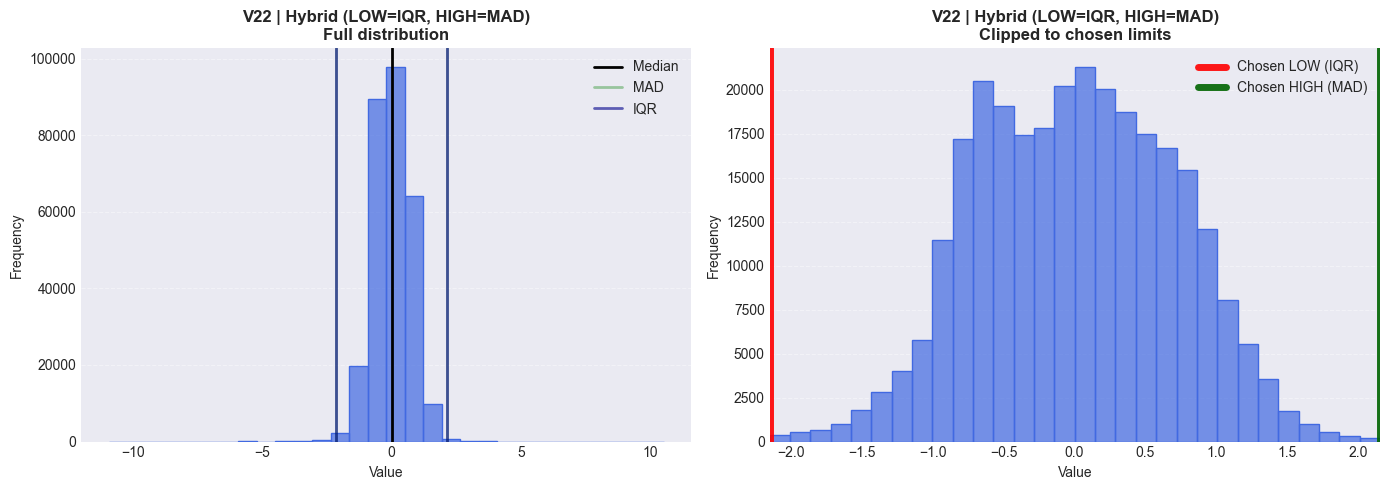

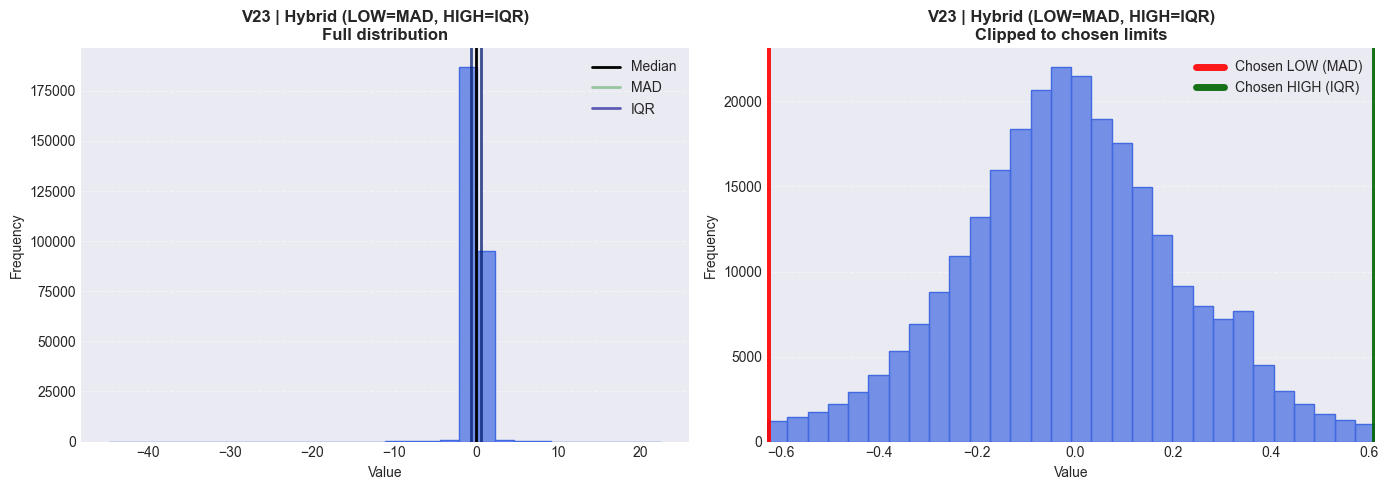

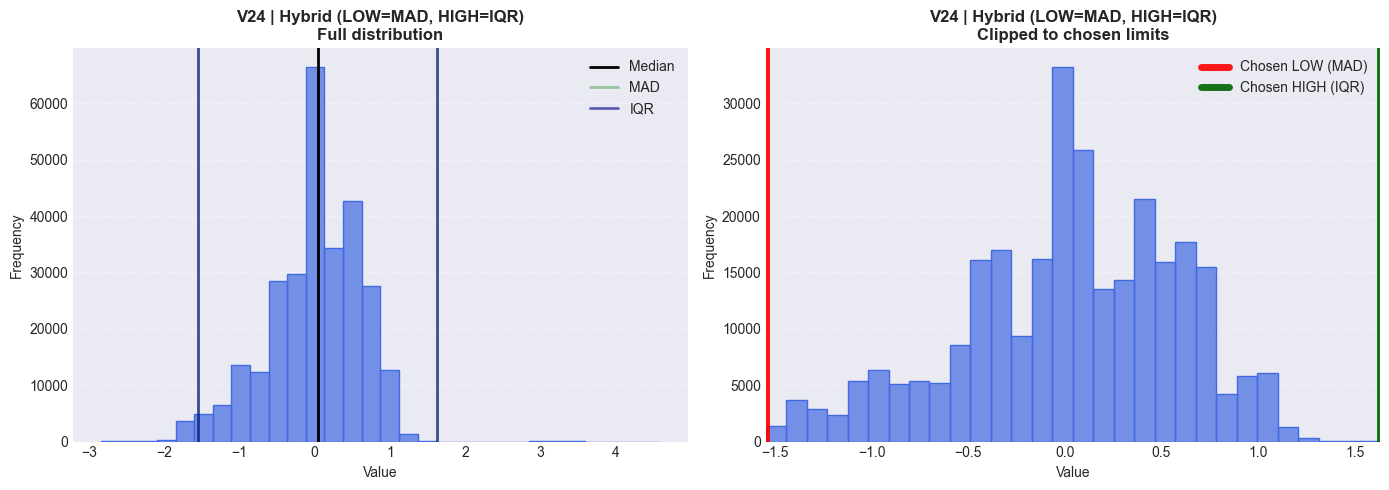

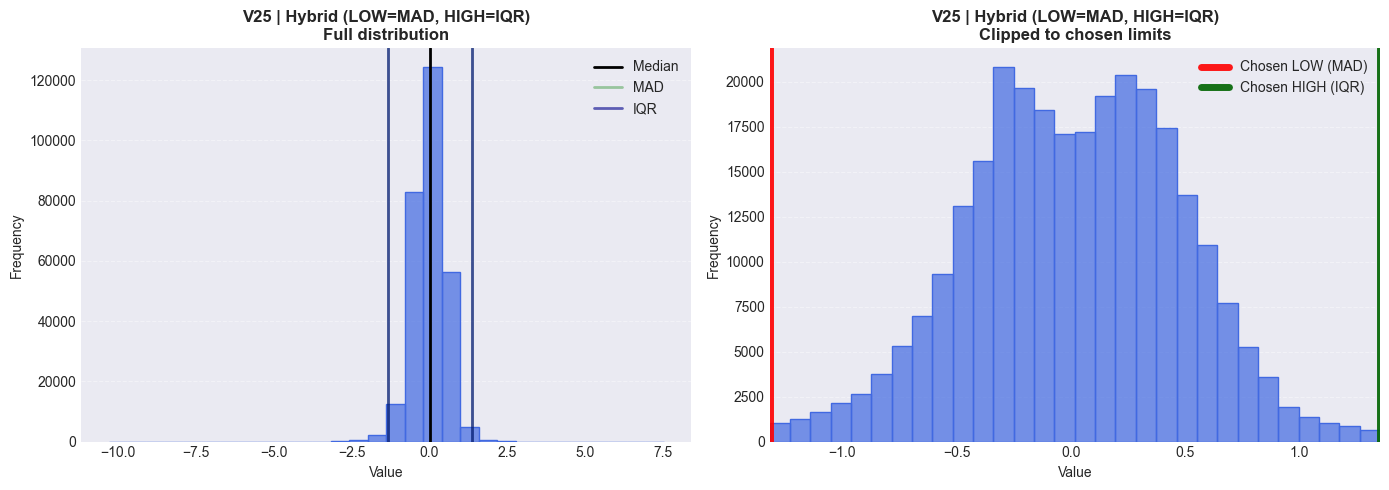

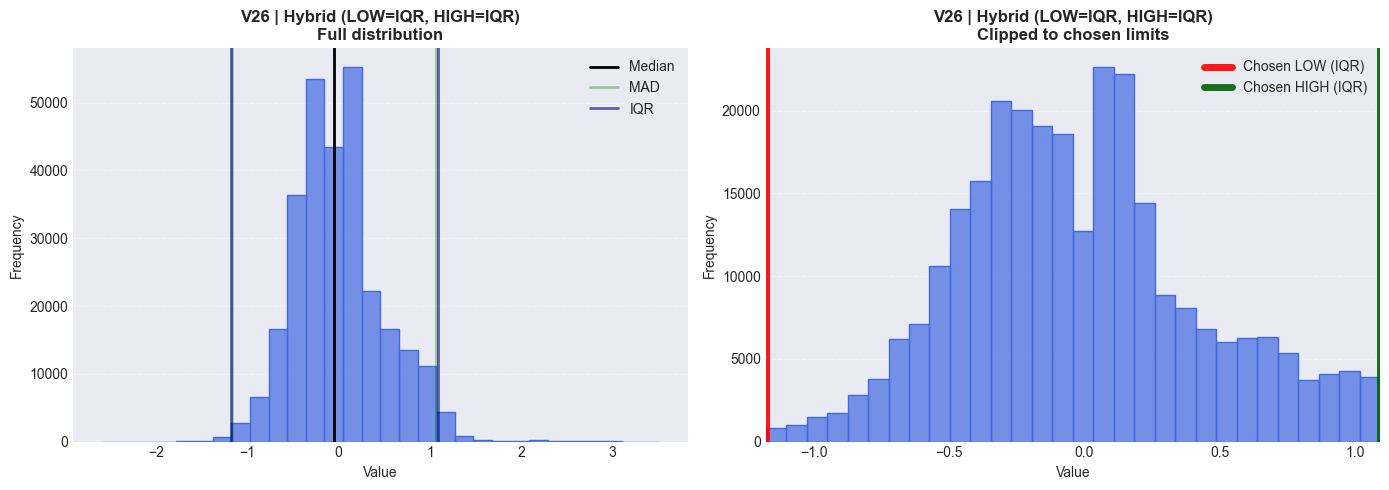

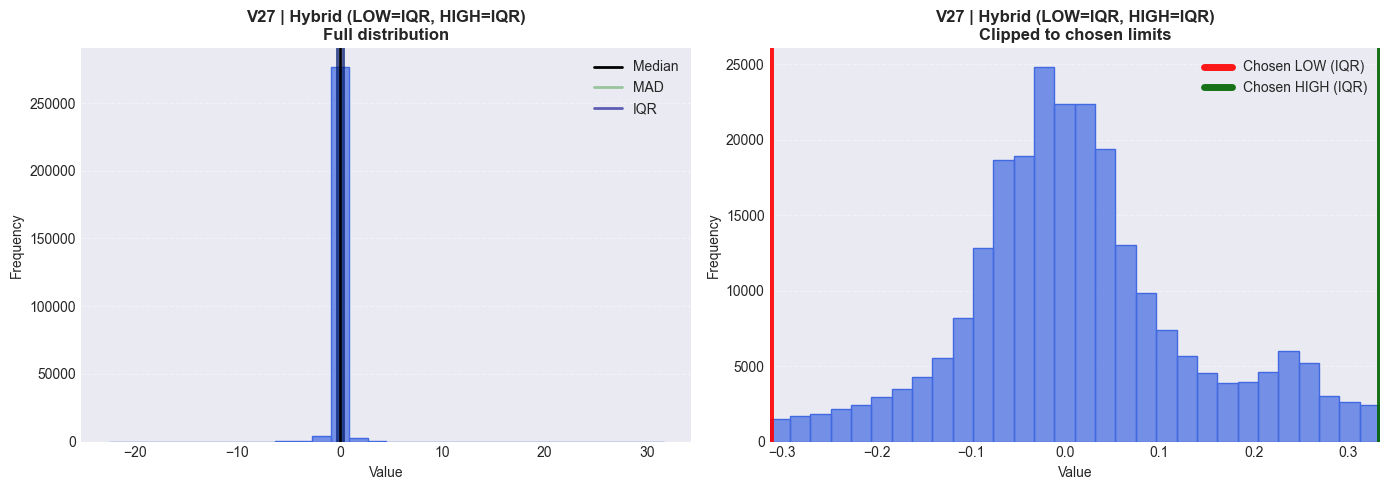

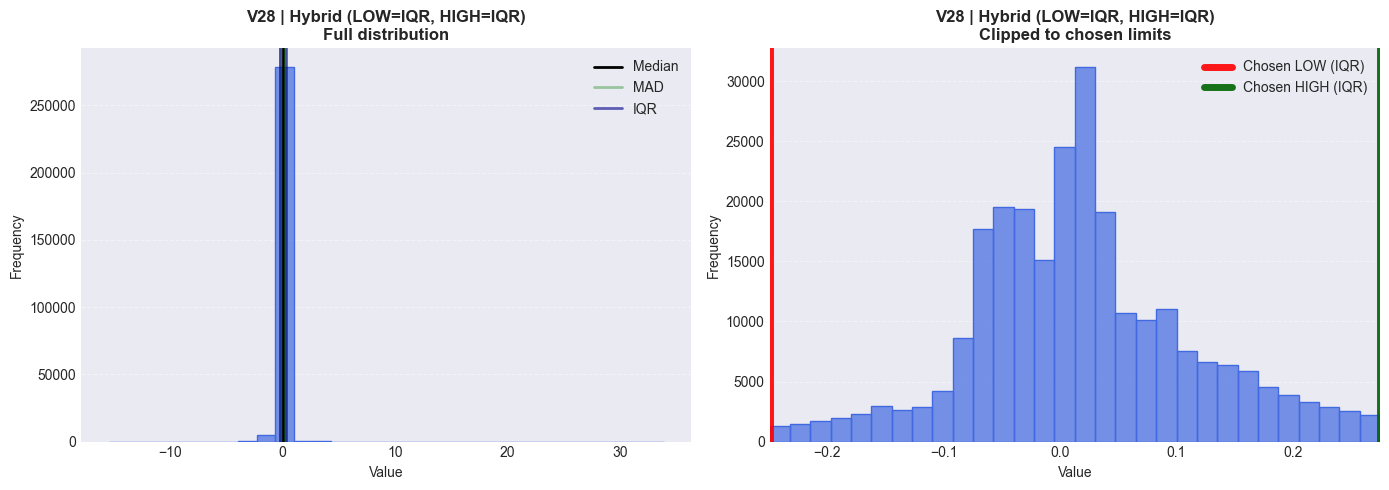

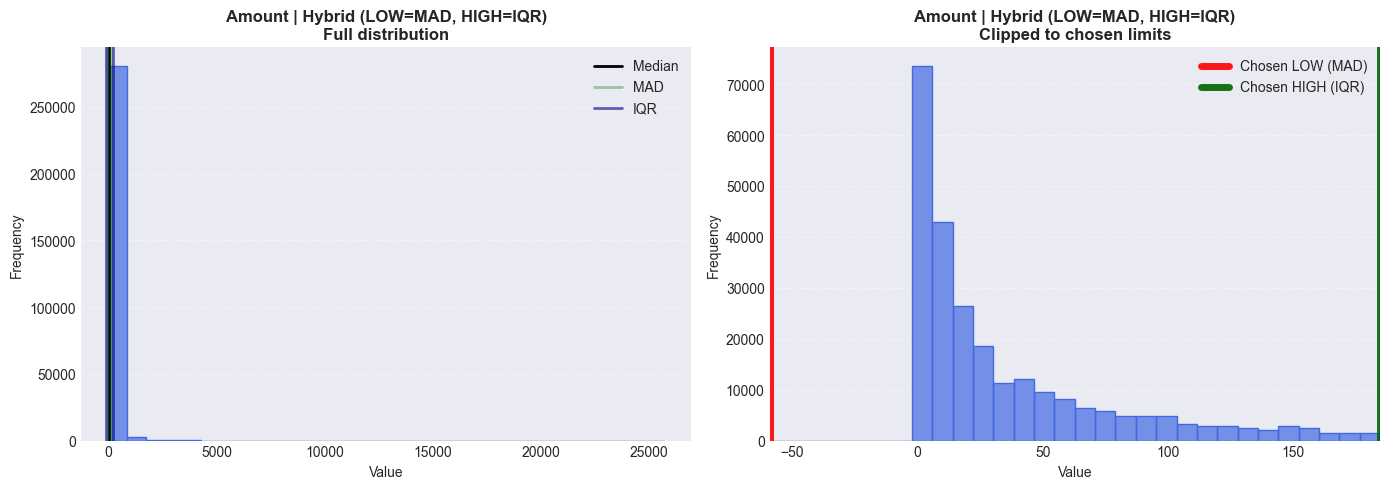

/var/folders/xp/kzk2h18n4zlbxxzkjlskcmnc0000gn/T/ipykernel_32725/3554764359.py:164: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax2.set_xlim(chosen_low, chosen_high)


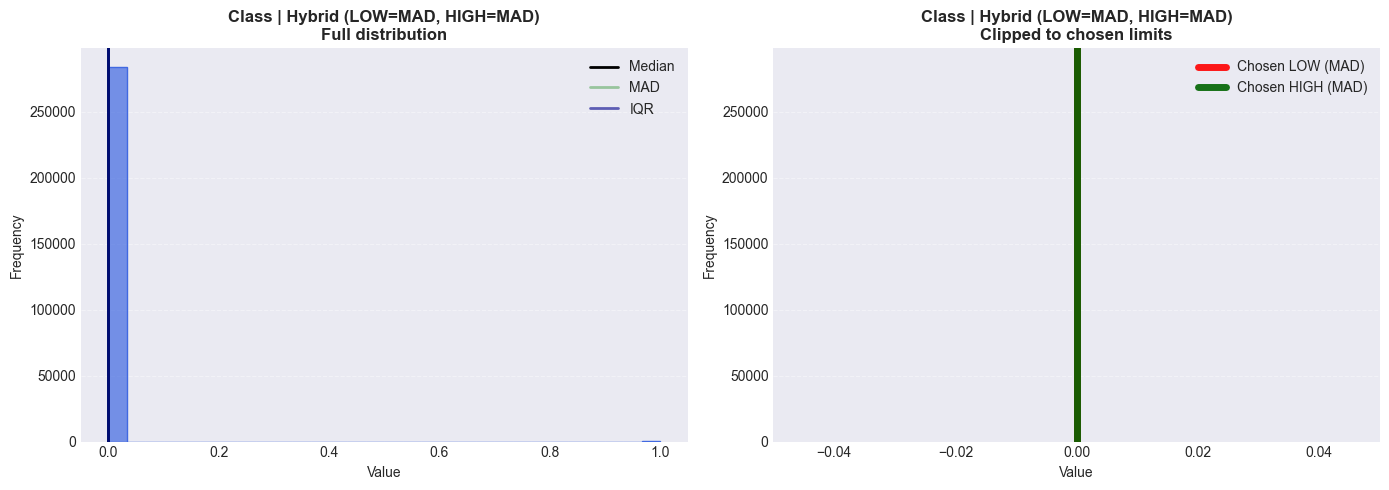

,column,status,chosen_low,chosen_low_method,chosen_high,chosen_high_method,low_mad,high_mad,low_iqr,high_iqr,below_count,above_count,median,mad,iqr,min,max
0,Amount,ok,-58.880000,MAD,184.512500,IQR,-58.880000,102.880000,-101.747500,184.512500,0,31904,22.000000,20.220000,71.565000,0.000000,25691.160000
1,Class,ok,0.000000,MAD,0.000000,MAD,0.000000,0.000000,0.000000,0.000000,0,492,0.000000,0.000000,0.000000,0.000000,1.000000
2,Time,ok,-73477.000000,IQR,255356.000000,MAD,-85972.000000,255356.000000,-73477.000000,266999.000000,0,0,84692.000000,42666.000000,85119.000000,0.000000,172792.000000
3,V1,ok,-4.760633,MAD,4.669664,IQR,-4.760633,4.796850,-4.274396,4.669664,5689,0,0.018109,1.194685,2.236015,-56.407510,2.454930
4,V10,ok,-2.019449,IQR,1.937947,IQR,-2.013247,1.827413,-2.019449,1.937947,3368,6128,-0.092917,0.480083,0.989349,-24.588262,23.745136
5,V11,ok,-3.033935,MAD,2.992725,IQR,-3.033935,2.968420,-3.015626,2.992725,115,661,-0.032757,0.750294,1.502088,-4.797473,12.018913
6,V12,ok,-1.941286,IQR,2.170261,MAD,-1.890196,2.170261,-1.941286,2.153952,14579,743,0.140033,0.507557,1.023810,-18.683715,7.848392
7,V13,ok,-2.634799,MAD,2.629071,IQR,-2.634799,2.607663,-2.615106,2.629071,1089,2229,-0.013568,0.655308,1.311044,-5.791881,7.126883
8,V14,ok,-1.803660,IQR,1.883080,MAD,-1.781877,1.883080,-1.803660,1.871236,8757,5250,0.050601,0.458120,0.918724,-19.214325,10.526766
9,V15,ok,-2.430442,IQR,2.510068,MAD,-2.413925,2.510068,-2.430442,2.496378,2465,411,0.048072,0.615499,1.231705,-4.498945,8.877742


In [23]:
limits_summary = detect_outliers_limits_all_numeric(
    df,
    mad_threshold=4.0,
    iqr_k=1.5,
    bins=30,
    max_plots=None
)

limits_summary